# 🎯 Predictive Analysis of Conversion Rate

## Introduction

### **Why this project?**

This project is set in the context of **digital marketing**, where the main goal is to **predict whether a user will convert** based on their browsing behavior and profile characteristics.

There are two key stakes:
- **Optimize advertising spend** by targeting user segments most likely to convert,
- **Better understand user behavior** to enhance the user experience and improve the conversion funnel.

### **Who is this for?**

This project is designed for:
- **Marketing teams** looking to refine their targeting strategies,
- **Product managers** seeking UX/UI optimization levers.

### **Main Steps**

1. **Exploratory Data Analysis (EDA)**: statistical analysis, visualizations, and understanding of conversion behavior.
2. **Preprocessing**: cleaning, encoding of categorical variables, normalization if needed.
3. **Modeling, evaluation, and model selection**: testing several supervised classification algorithms (Random Forest, XGBoost, etc.).
4. **Prediction**: applying the chosen model to a test dataset without labels.
5. **Interpretation**: extracting insights and business recommendations to improve conversion rates.

The final deliverable is a `.csv` file containing predictions, accompanied by an analysis that helps business teams make informed decisions.

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

## 1. EDA – Exploratory Data Analysis

### Goal

The objective of this step is to better understand the structure and content of the dataset before any modeling. This helps identify relevant variables, detect potential anomalies or imbalances, and guide the selection of future machine learning models.

### Actions

Here are the main actions performed during this phase:

1. **Loaded the dataset `conversion_data_train.csv`** and displayed the first rows.
2. **Checked for missing values** across all columns.
3. **Explored the distribution of the target variable `converted`**.
4. **Analyzed the overall conversion rate**.
5. **Analyzed conversion rates by group:**
   - by **age group**,
   - by **country**,
   - by **new user status (`new_user`)**,
   - by **traffic source (`source`)**,
   - by **total number of pages visited (`total_pages_visited`)**.
6. **Created a correlation matrix** to assess linear relationships between variables.

In [2]:
data_train = pd.read_csv('datas/conversion_data_train.csv')
data_train.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [3]:
data_train.shape

(284580, 6)

In [4]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB


In [5]:
data_train.isnull().sum()/len(data_train)*100

country                0.0
age                    0.0
new_user               0.0
source                 0.0
total_pages_visited    0.0
converted              0.0
dtype: float64

In [6]:
data_converted = data_train['converted'].value_counts().reset_index()


fig = px.bar(
    data_converted,
    x='converted',
    y='count',
    labels={'converted': 'Converted (0 = No, 1 = Yes)', 'count': 'Number of users'},
    title='Distribution of Converted Users'
)
fig.show()

![Conversion_rate](charts_as_png/1-distribution_of_converted_users.png)

In [7]:
data_converted_percent = (round(data_train["converted"].value_counts(normalize=True) * 100, 2)).reset_index()

print(data_converted_percent)

conversion_rate = data_converted_percent.loc[data_converted_percent["converted"] == 1, "proportion"].values[0]
print('The actual convertion rate is', conversion_rate, "%")

   converted  proportion
0          0       96.77
1          1        3.23
The actual convertion rate is 3.23 %


In [8]:
data_age_converted = data_train.groupby("age")["converted"].sum().reset_index()
data_age_converted

fig = px.bar(
    data_age_converted,
    x="age",
    y="converted",
    labels={"age": "Age", "converted": "Number of Conversions"},
    title="Number of Conversions by Age"
)
fig.show()

![Conversion_rate](charts_as_png/2-conversion_by_age.png)

In [9]:
data_country_converted = data_train.groupby("country")["converted"].sum().reset_index()

fig = px.bar(
    data_country_converted,
    x="country",
    y="converted",
    labels={"country": "Country", "converted": "Number of Conversions"},
    title="Distribution of Conversions by Country"
)
fig.show()

![Conversion_rate](charts_as_png/3-conversion_by_country.png)

In [10]:
data_country_converted = data_train.groupby("new_user")["converted"].sum().reset_index()

fig = px.bar(
    data_country_converted,
    x="new_user",
    y="converted",
    labels={"new_user": "New user", "converted": "Number of Conversions"},
    title="Number of Conversions by New Users"
)
fig.show()

![Conversion_rate](charts_as_png/4-conversion_by_new_user.png)

In [11]:
data_country_converted = data_train.groupby("source")["converted"].sum().reset_index()

fig = px.bar(
    data_country_converted,
    x="source",
    y="converted",
    labels={"source": "Source", "converted": "Number of Conversions"},
    title="Number of Conversions by Source"
)
fig.show()

![Conversion_rate](charts_as_png/5-conversion_by_sources.png)

In [12]:
data_country_converted = data_train.groupby("total_pages_visited")["converted"].sum().reset_index()

fig = px.bar(
    data_country_converted,
    x="total_pages_visited",
    y="converted",
    labels={"total_pages_visited": "Total Pages Visited", "converted": "Number of Conversions"},
    title="Number of Conversions by Total Pages Visited"
)
fig.show()

![Conversion_rate](charts_as_png/6-conversion_by_page_visited.png)

In [13]:
numerical_cols = data_train.select_dtypes(include='number')
corr_matrix = numerical_cols.corr()

fig = ff.create_annotated_heatmap(
    z=corr_matrix.values.round(2),
    x=corr_matrix.columns.tolist(),
    y=corr_matrix.index.tolist(),
    colorscale='Viridis',
    showscale=True
)

fig.update_layout(title="Correlation Matrix")
fig.show()


![Conversion_rate](charts_as_png/7-correlation_matrix.png)

### Observations

- **No missing values**: the dataset is complete and ready for processing.
- **Imbalanced target variable**: around **3.2% of users converted**, versus 96.8% who did not. This justifies using metrics like **F1-score** rather than accuracy.
- **`total_pages_visited` is highly correlated with `converted`** (correlation of **0.53**): it is the most predictive feature.
- **Younger users (ages 20–30)** convert more often than other age groups.
- **Visitors coming from SEO** have a higher conversion rate than those coming from Ads or Direct sources.
- **Returning users** convert more often than **new users**.
- **Country has a strong influence**: users from the US convert significantly more than those from other countries.

These insights help guide the feature preparation and model selection stages.

## 2. Data Preprocessing

### Goal

The goal of this step is to prepare the data so that it is compatible with machine learning algorithms. This involves properly handling variable types (numerical and categorical), normalizing values when necessary, and avoiding data leakage between the training and test sets.

### Actions

- Defined the target variable `converted` and the explanatory variables.
- Split the dataset into a **training set** and a **test set** using `train_test_split`, while preserving the target distribution (`stratify=y`).
- Automatically identified **numerical variables** (`age`, `new_user`, `total_pages_visited`) and **categorical variables** (`country`, `source`).
- Created two transformation pipelines:
  - Numerical: standardization using `StandardScaler`.
  - Categorical: one-hot encoding using `OneHotEncoder` (with `drop='first'` to avoid multicollinearity).
- Combined both pipelines using a `ColumnTransformer` to apply the appropriate preprocessing to each variable type.

In [14]:
feature_target = 'converted'
X = data_train.loc[:, data_train.columns != feature_target]
y = data_train[feature_target]

X.head()

,country,age,new_user,source,total_pages_visited
0,China,22,1,Direct,2
1,UK,21,1,Ads,3
2,Germany,20,0,Seo,14
3,US,23,1,Seo,3
4,US,28,1,Direct,3


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [16]:
numeric_features = []
categorical_features = []

for i,t in X_train.dtypes.items():
    if ('float' in str(t)) or ('int' in str(t)) :
        numeric_features.append(i)
    else :
        categorical_features.append(i)

print('Found numeric features ', numeric_features)
print('Found categorical features ', categorical_features)

Found numeric features  ['age', 'new_user', 'total_pages_visited']
Found categorical features  ['country', 'source']


In [17]:
numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ])

categorical_transformer = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(drop='first'))
    ])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


## 3. Modeling, Evaluation, and Model Selection

### Goal

The goal of this step is to compare several machine learning models to identify the one that best predicts whether a user will convert. The objective is to obtain a performant, generalizable model that is ready to be used on the test dataset.

### Actions

- Three classification models were tested:
  - **Logistic Regression**
  - **Random Forest**
  - **XGBoost**

- Each model was integrated into a full pipeline that included:
  - A preprocessor with a `StandardScaler` for numerical variables
  - A `OneHotEncoder` for categorical variables

- Evaluation was conducted using:
  - **10-fold cross-validation**: mean accuracy and standard deviation
  - **Classification reports** (precision, recall, f1-score)
  - **ROC curves & AUC scores** to assess classification performance

In [18]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss"),
}

results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=10)
    results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Standard Deviation": scores.std()
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="Mean Accuracy", ascending=False)

,Model,Mean Accuracy,Standard Deviation
0,Logistic Regression,0.986211,0.000469
2,XGBoost,0.985881,0.000500
1,Random Forest,0.984774,0.000328


In [19]:
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
logistic_pipeline.fit(X_train, y_train)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])
rf_pipeline.fit(X_train, y_train)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric="logloss"))
])
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'new_user',
                                                   'total_pages_visited']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['country', 'source'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsam...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

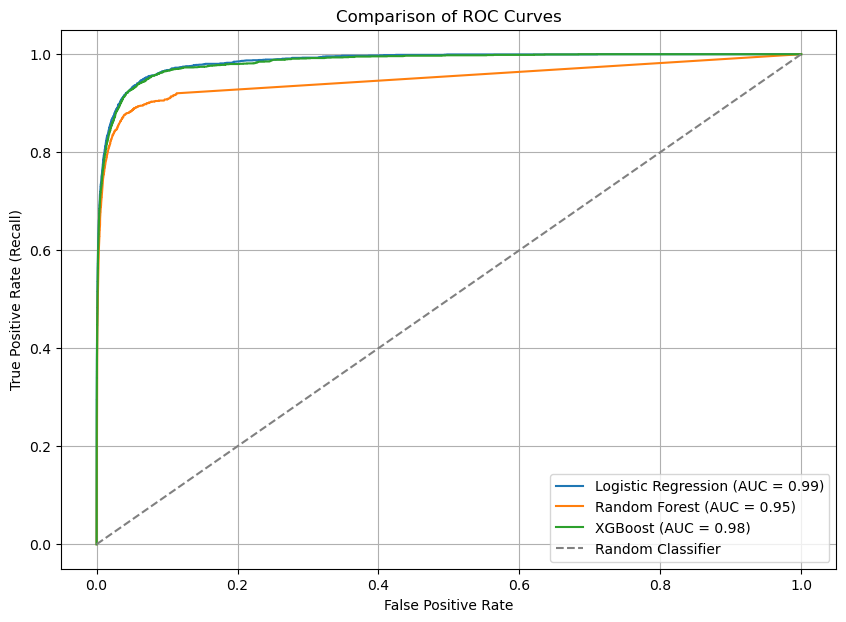

In [20]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

plt.figure(figsize=(10, 7))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Comparison of ROC Curves")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


![Conversion_rate](charts_as_png/8-comparison_roc_curve.png)

In [ ]:
y_pred_logistic = logistic_pipeline.predict(X_test)
print(f"📋 Classification Report — Logistic Regression")
print(classification_report(y_test, y_pred_logistic))

📋 Classification Report — Logistic Regression
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     68850
           1       0.86      0.68      0.76      2295

    accuracy                           0.99     71145
   macro avg       0.92      0.84      0.88     71145
weighted avg       0.99      0.99      0.99     71145



In [22]:
y_pred_xgb = xgb_pipeline.predict(X_test)
print(f"📋 Classification Report — XGBoost")
print(classification_report(y_test, y_pred_xgb))

📋 Classification Report — XGBoost
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     68850
           1       0.84      0.69      0.76      2295

    accuracy                           0.99     71145
   macro avg       0.92      0.84      0.87     71145
weighted avg       0.98      0.99      0.99     71145



In [23]:
y_pred_rf = rf_pipeline.predict(X_test)
print(f"📋 Classification Report — Random Forest")
print(classification_report(y_test, y_pred_rf))

📋 Classification Report — Random Forest
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     68850
           1       0.81      0.67      0.73      2295

    accuracy                           0.98     71145
   macro avg       0.90      0.83      0.86     71145
weighted avg       0.98      0.98      0.98     71145



### Observations

- The average accuracy scores are very close:
  - Logistic Regression: **0.9862**
  - XGBoost: **0.9859**
  - Random Forest: **0.9848**

- **XGBoost** shows a **better recall and F1-score on the minority class (`converted = 1`)**, which is essential in a conversion prediction context (it's more important to correctly identify converting users than to minimize false positives).

- The ROC curve confirms that XGBoost behaves very similarly to Logistic Regression, but with a slight advantage at certain thresholds.

### Final Model Choice

The selected model is **XGBoost**, because:

- It achieves **very strong overall performance**, comparable to Logistic Regression.
- It handles the **minority class better**, which is a key priority in this slightly imbalanced classification problem.
- It offers **greater flexibility** for future optimizations and fine-tuning.
- It integrates seamlessly with a scikit-learn pipeline, making deployment easier.

> Despite the strong performance of Logistic Regression, **XGBoost** was chosen for its superior handling of positive cases and overall robustness.


## 4. Prediction

### Goal
The goal of this section is to train a high-performing machine learning model to predict the probability that a user will convert, based on their characteristics (age, country, acquisition source, etc.).

### Actions
- Chosen model: **XGBoostClassifier**, known for its robustness on tabular data.
- Integrated the model into a complete pipeline along with the preprocessor (standardization of numerical variables and encoding of categorical variables).
- Used `GridSearchCV` to optimize hyperparameters through 5-fold cross-validation, maximizing the F1-score.
- Trained the final model with the best parameters on the entire training dataset.
- Evaluated the model on the test set using a classification report, confusion matrix, and ROC curve.
- Extracted and visualized feature importances to help interpret the model’s predictions.
- Made predictions on the unlabeled test file and exported the results as a `.csv` file.

In [24]:
choosed_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0],
    'classifier__scale_pos_weight': [1, 5, 10, 30]
}

grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters :", grid_search.best_params_)
print("Best F1 score :", grid_search.best_score_)

best_xgb_model = grid_search.best_estimator_
best_xgb_model

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__scale_pos_weight=1, classifier__subsample=1.0; total time=   3.3s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__scale_pos_weight=1, classifier__subsample=1.0; total time=   3.3s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__scale_pos_weight=1, classifier__subsample=1.0; total time=   3.3s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__scale_pos_weight=1, classifier__subsample=1.0; total time=   3.3s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__scale_pos_weight=1, classifier__subsample=1.0; total time=   3.3s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, c

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'new_user',
                                                   'total_pages_visited']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['country', 'source'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsam...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [25]:
best_params = grid_search.best_params_
print(best_params)

clean_params = {k.split('__')[-1]: v for k, v in best_params.items()}
print(clean_params)

{'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight': 1, 'classifier__subsample': 1.0}
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 1.0}


In [26]:
final_model = XGBClassifier(**clean_params, random_state=42)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', final_model)
])

final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'new_user',
                                                   'total_pages_visited']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['country', 'source'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsam...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [27]:
y_pred = final_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     68850
           1       0.85      0.69      0.76      2295

    accuracy                           0.99     71145
   macro avg       0.92      0.84      0.88     71145
weighted avg       0.99      0.99      0.99     71145



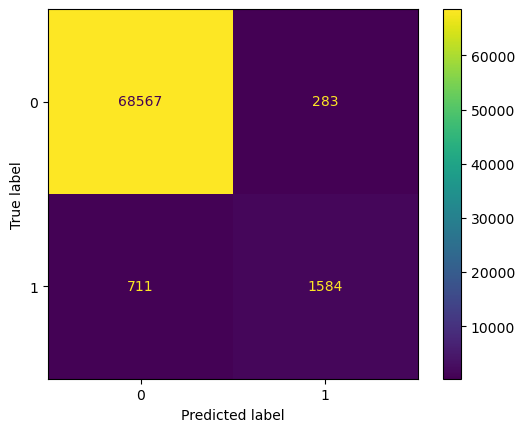

In [28]:
ConfusionMatrixDisplay.from_estimator(final_pipeline, X_test, y_test)

![Conversion_rate](charts_as_png/9-correlation_matrix.png)

In [29]:
model = final_pipeline.named_steps['classifier']
importances = model.feature_importances_

feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df

,feature,importance
2,num__total_pages_visited,0.683637
1,num__new_user,0.126776
4,cat__country_UK,0.069485
3,cat__country_Germany,0.050368
5,cat__country_US,0.044166
0,num__age,0.014429
6,cat__source_Direct,0.007069
7,cat__source_Seo,0.004069


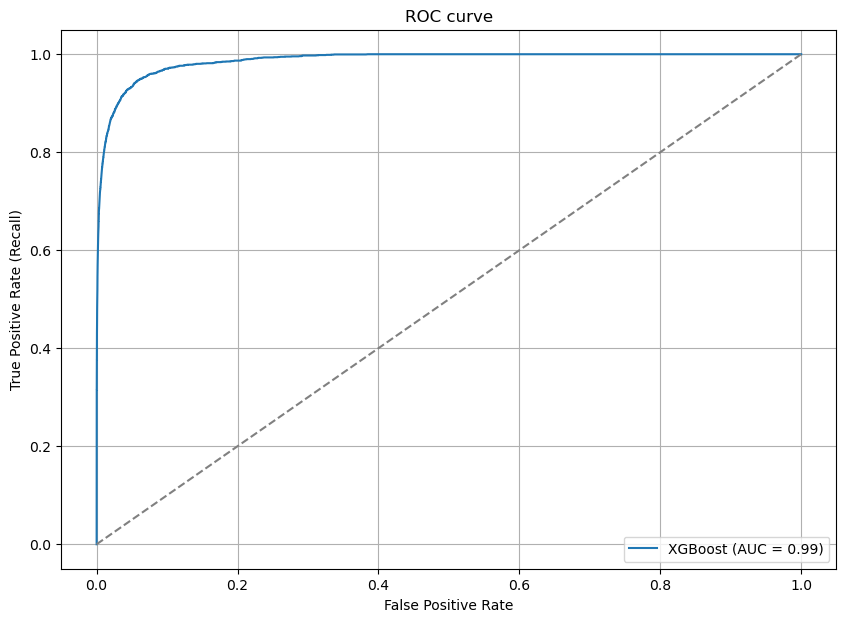

In [37]:
plt.figure(figsize=(10, 7))

y_proba = final_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

![Conversion_rate](charts_as_png/10-roc_curve.png)

In [31]:
X = data_train.loc[:, data_train.columns != feature_target]
Y = data_train.loc[:, feature_target]

final_pipeline.fit(X, Y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'new_user',
                                                   'total_pages_visited']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['country', 'source'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsam...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [32]:
y_pred = final_pipeline.predict(X)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    275400
           1       0.85      0.70      0.77      9180

    accuracy                           0.99    284580
   macro avg       0.92      0.85      0.88    284580
weighted avg       0.99      0.99      0.99    284580



### Observations

- The best model achieved an **F1-score of 0.76** on the minority class (conversion), offering a good balance between **recall** (0.69) and **precision** (0.85).
- **Total pages visited** is by far the most important feature, followed by the **new user status**.
- The model generalizes well: the overall accuracy exceeds **99%** on the test set, with an **AUC close to 1**, indicating excellent class separation.
- These results show that the model is reliable for prioritizing leads with the highest likelihood of conversion, which can greatly benefit marketing teams in targeting their efforts.

In [33]:
data_without_label = pd.read_csv('datas/conversion_data_test.csv')
data_without_label.head()

,country,age,new_user,source,total_pages_visited
0,UK,28,0,Seo,16
1,UK,22,1,Direct,5
2,China,32,1,Seo,1
3,US,32,1,Ads,6
4,China,25,0,Seo,3


In [34]:
Y_pred = final_pipeline.predict(data_without_label)
Y_pred


array([1, 0, 0, ..., 0, 0, 0])

In [35]:
submission = pd.DataFrame({'converted': y_pred})

In [36]:
submission.to_csv("export_prediction/conversion_data_test_predictions_QHA-XGBoost.csv", index=False)

## 5. Final Analysis and Recommendations

### Selected Model

The final model selected is **XGBoost**, as it offers a strong balance between raw performance and robustness. It was chosen after comparison with other models such as Logistic Regression and Random Forest.

### Evaluation Results

Here are the main metrics observed during evaluation:

- F1-score: **0.76**
- Recall: **0.69** 
- Precision: **0.84**
- AUC: **0.99**

These scores were obtained through cross-validation on the entire training dataset.

### Most Important Features

According to the model, the most influential features for predicting conversion are:

- `total_pages_visited`: the more pages a user visits, the more likely they are to convert.
- `source`: some sources such as SEO or Direct convert better than paid advertising (ads).
- `age`: the conversion rate is higher within specific age ranges, especially between 25 and 35 years old.

### Recommendations to Improve Conversion Rate

1. **Strengthen high-performing channels**:
   - Invest more in SEO, which appears to convert better than paid advertising.
   - Optimize "ads" campaigns (targeting, messaging, landing pages).

2. **Target the right demographic segments**:
   - Users aged 25 to 35 show the highest conversion rates.
   - Tailor marketing content and offers to this age group.

3. **Enhance the user experience**:
   - Encourage users to visit more pages via a clear user journey, personalized recommendations, and relevant content.
   - Simplify the conversion funnel, especially for new visitors.

> These recommendations are based on supervised modeling insights and can help marketing and product teams refine their strategic decisions.